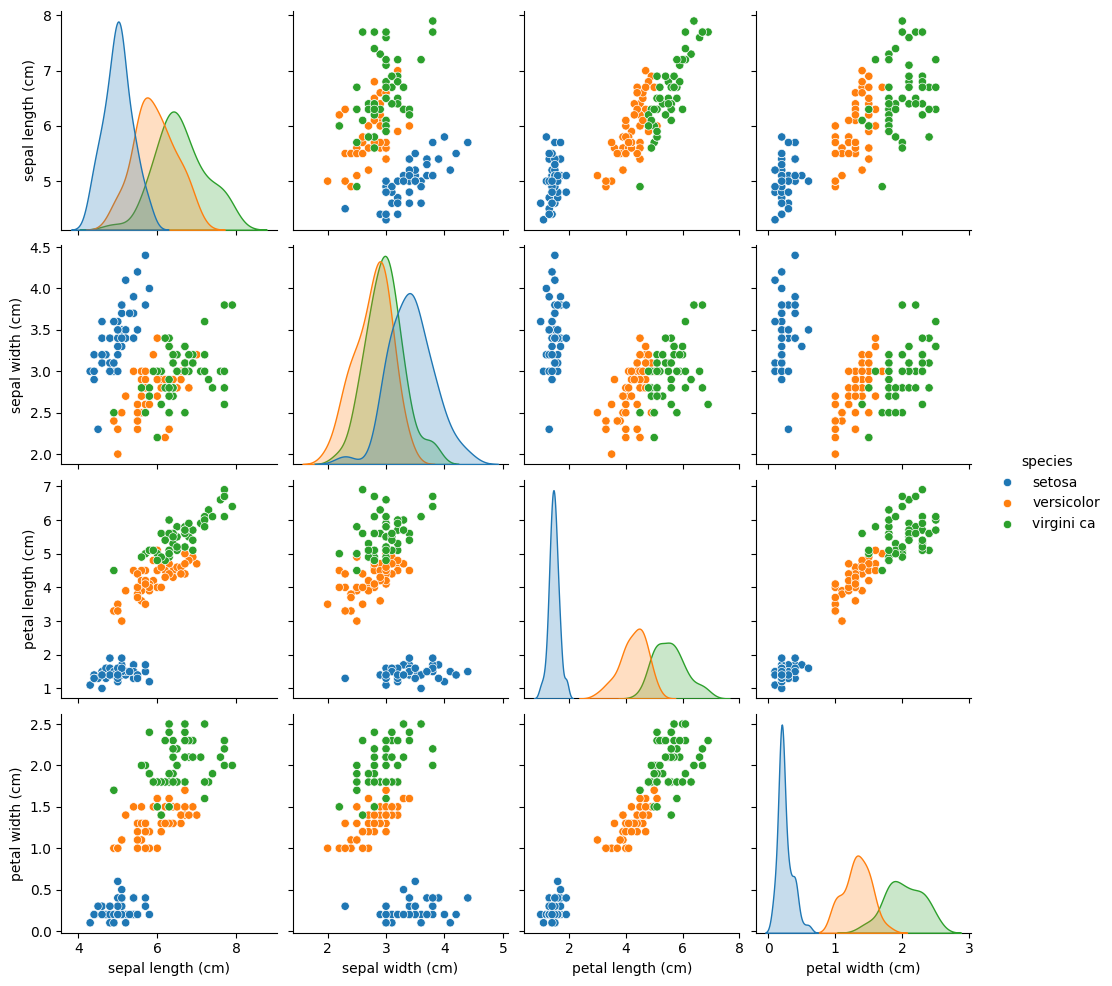

In [2]:
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt

iris = load_iris()

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['species'] = iris.target

iris_df['species'] = iris_df['species'].map({0: 'setosa', 1: 'versicolor', 2: 'virgini ca'})

#sns.pairplot(iris_df, hue='species', markers=["o", "s", "D"]) # hue meaning: color by species, markers meaning: different shapes for different species
# alternative plot
sns.pairplot(iris_df, hue='species', diag_kind='kde') # diag_kind meaning: use kernel density estimation for the diagonal plots

plt.show()


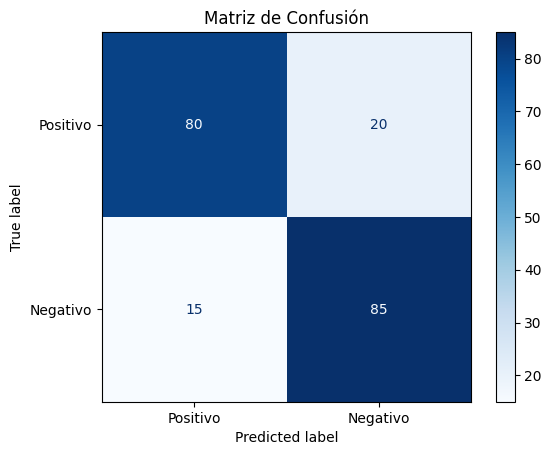

Reporte de Clasificación:

              precision    recall  f1-score   support

    Positivo       0.81      0.85      0.83       100
    Negativo       0.84      0.80      0.82       100

    accuracy                           0.82       200
   macro avg       0.83      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200


Métricas individuales calculadas:
Accuracy: 0.82
Precision: 0.84
Recall: 0.80
F1-Score: 0.82


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

y_true = [1] * 80 + [0] * 85 + [1] * 20 + [0] * 15  # Valores reales
y_pred = [1] * 80 + [0] * 20 + [1] * 15 + [0] * 85  # Predicciones

cm = confusion_matrix(y_true, y_pred, labels=[1, 0])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positivo", "Negativo"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()

print("Reporte de Clasificación:\n")
print(classification_report(y_true, y_pred, target_names=["Positivo", "Negativo"]))

accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
precision = cm[0, 0] / (cm[0, 0] + cm[1, 0])
recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nMétricas individuales calculadas:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")


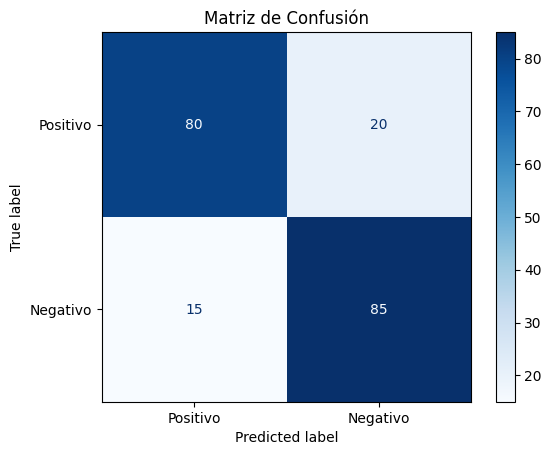

Reporte de Clasificación:

              precision  recall  f1-score  support
Positivo       0.809524   0.850  0.829268  100.000
Negativo       0.842105   0.800  0.820513  100.000
accuracy       0.825000   0.825  0.825000    0.825
macro avg      0.825815   0.825  0.824891  200.000
weighted avg   0.825815   0.825  0.824891  200.000

Métricas individuales:
Accuracy: 0.82
Precision: 0.84
Recall: 0.80
F1-Score: 0.82

Tabla de métricas:

     Métrica     Valor
0   Accuracy  0.825000
1  Precision  0.842105
2     Recall  0.800000
3   F1-Score  0.820513

Interpretación:
1. Si te interesa identificar todos los casos positivos (minimizar los FN), optimiza el Recall.
2. Si prefieres evitar falsos positivos (FP), optimiza la Precision.
3. Para un balance general entre Precision y Recall, mejora el F1-Score.
4. Si el dataset no está desbalanceado, el Accuracy es una métrica adecuada.



In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay


# Supongamos que estamos clasificando si un paciente tiene una enfermedad (1) o no (0).

# Datos reales (y_true): 1 representa enfermedad, 0 representa no enfermedad
y_true = [1] * 80 + [0] * 85 + [1] * 20 + [0] * 15  # 80 positivos reales, 85 negativos reales
# Predicciones del modelo (y_pred): resultados predichos por un clasificador
y_pred = [1] * 80 + [0] * 20 + [1] * 15 + [0] * 85  # 80 TP, 15 FP, 20 FN, 85 TN


cm = confusion_matrix(y_true, y_pred, labels=[1, 0])



disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positivo", "Negativo"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión")
plt.show()



# Métricas generales con sklearn
report = classification_report(y_true, y_pred, target_names=["Positivo", "Negativo"], output_dict=True)

report_df = pd.DataFrame(report).transpose()
print("Reporte de Clasificación:\n")
print(report_df)

accuracy = (cm[0, 0] + cm[1, 1]) / cm.sum()
precision = cm[0, 0] / (cm[0, 0] + cm[1, 0])
recall = cm[0, 0] / (cm[0, 0] + cm[0, 1])
f1_score = 2 * (precision * recall) / (precision + recall)

print("\nMétricas individuales:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1_score:.2f}")



metrics_df = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Valor": [accuracy, precision, recall, f1_score]
})


print("\nTabla de métricas:\n")
print(metrics_df)


# Texto explicativo sobre cuándo mejorar cada métrica
print("""
Interpretación:
1. Si te interesa identificar todos los casos positivos (minimizar los FN), optimiza el Recall.
2. Si prefieres evitar falsos positivos (FP), optimiza la Precision.
3. Para un balance general entre Precision y Recall, mejora el F1-Score.
4. Si el dataset no está desbalanceado, el Accuracy es una métrica adecuada.
""")
